## Dataset Description

Esse conjunto de dados, intitulado Pima Indians Diabetes Data Set, foi originalmente do National Institute of Diabetes and Digestive and Kidney Diseases, cujo objetivo é prever se o paciente tem diabetes. Os pacientes selecionados são mulheres com pelo menos 21 de herança indiana Prima. As informações da base de dados são descritas a seguir.
Atributos do dataset:

    Pregnancies: número de vezes grávida
    Glucose: concentração plasmática de glicose a 2 horas em um teste oral de tolerância à glicose
    BloodPressure: pressão arterial diastólica (mm Hg)
    SkinThickness: espessura da dobra da pele do tríceps (mm)
    Insulin: insulina sérica de 2 horas (mu U/ml)
    BMI: índice de massa corporal (peso em kg / (altura em m) ^ 2)
    DiabetesPedigreeFunction: função de pedigree do diabetes
    Age: idade (anos)
    Outcome: variável de classe (0 ou 1) para diabetes


In [31]:
# Load dataset 
import pandas as pd

DATASET_PATH = "../../diabetes_dataset.csv"

def load_dataset(path=DATASET_PATH):
    return pd.read_csv(path)

dataset = load_dataset()
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
4,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0


In [32]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               572 non-null    int64  
 1   Glucose                   567 non-null    float64
 2   BloodPressure             537 non-null    float64
 3   SkinThickness             345 non-null    float64
 4   Insulin                   198 non-null    float64
 5   BMI                       561 non-null    float64
 6   DiabetesPedigreeFunction  572 non-null    float64
 7   Age                       572 non-null    int64  
 8   Outcome                   572 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 40.3 KB


In [33]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,572.000000,567.000000,537.000000,345.000000,198.000000,561.000000,572.000000,572.000000,572.000000
mean,4.106643,121.647266,73.150838,29.356522,156.934343,32.327629,0.459121,34.043706,0.358392
std,3.446995,30.132084,12.347184,10.433503,119.066934,6.735437,0.336124,12.103893,0.479948
min,0.000000,44.000000,30.000000,7.000000,16.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,65.000000,22.000000,77.500000,27.500000,0.236000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,30.000000,129.500000,32.000000,0.344500,30.000000,0.000000
75%,6.000000,140.000000,80.000000,36.000000,185.000000,36.600000,0.605500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,57.300000,2.329000,81.000000,1.000000


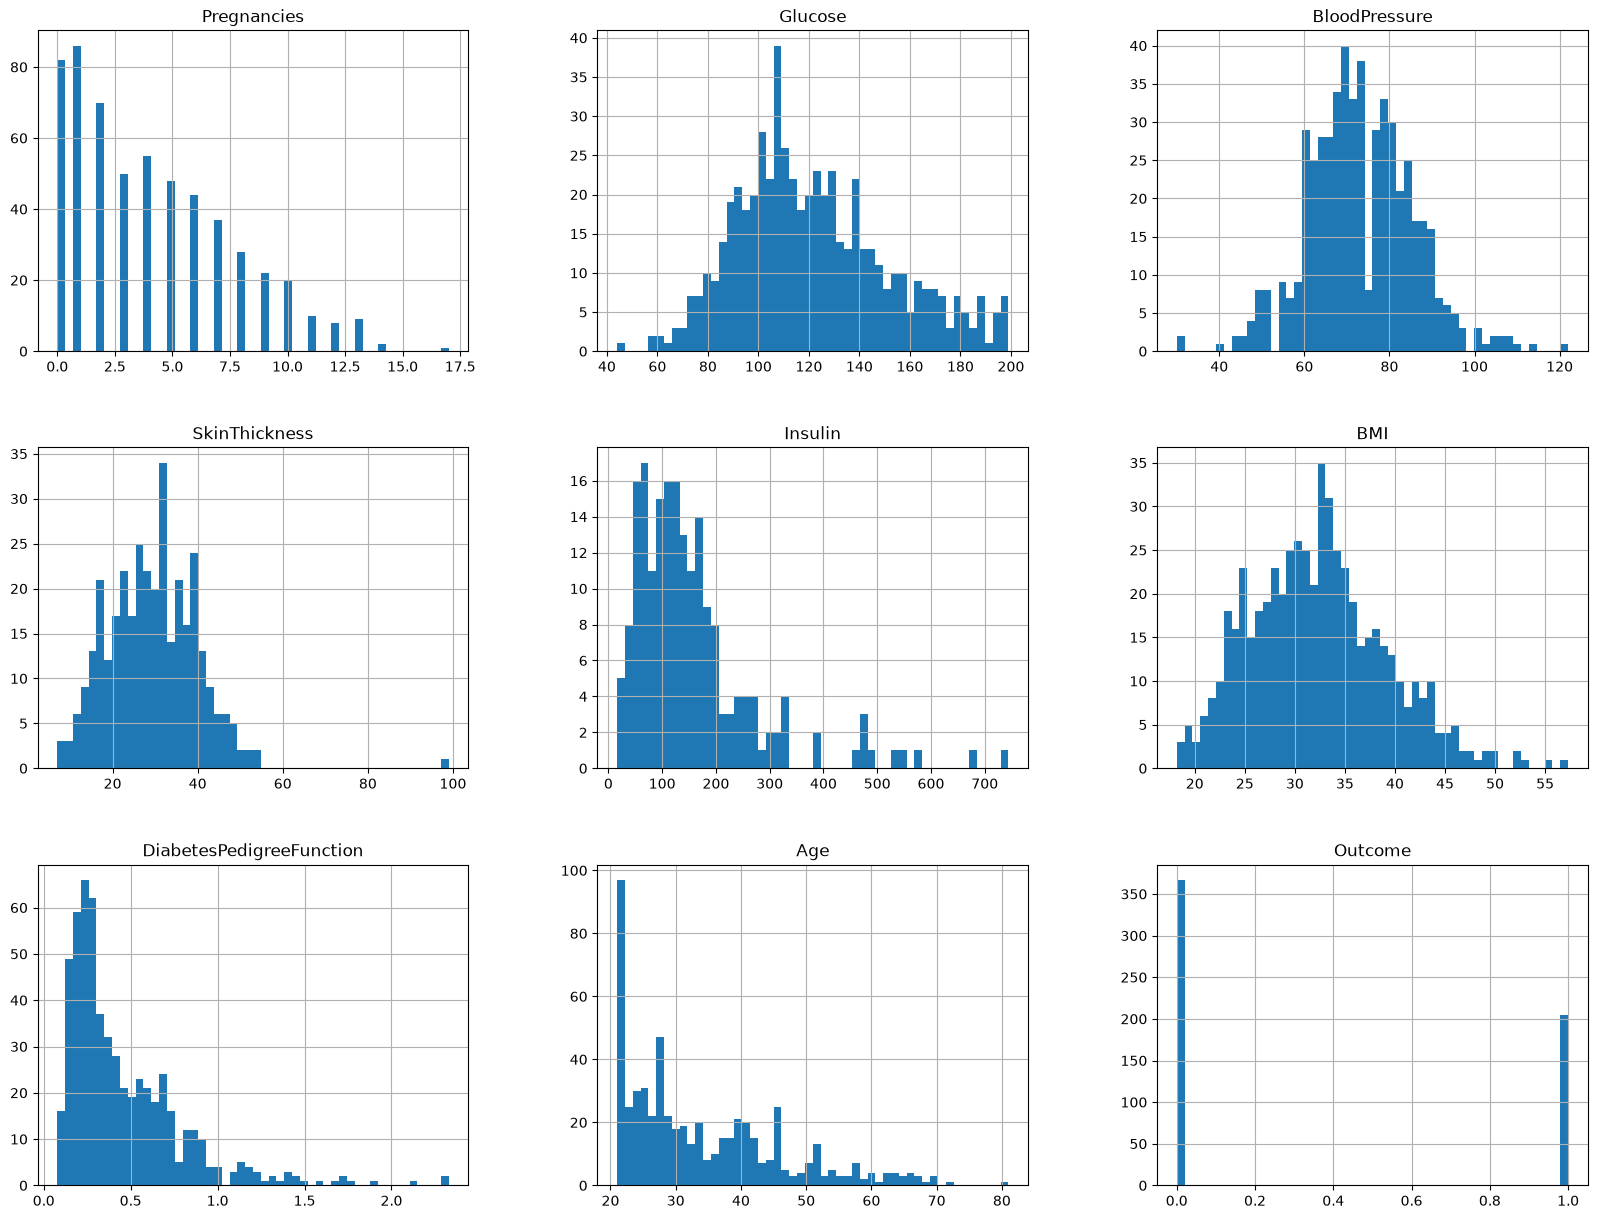

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt

dataset.hist(bins=50, figsize=(20,15))
plt.show()

In [35]:
corr_matrix = dataset.corr()
corr_matrix["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.480425
BMI                         0.308132
Insulin                     0.274332
SkinThickness               0.252870
Pregnancies                 0.185400
DiabetesPedigreeFunction    0.171984
Age                         0.171850
BloodPressure               0.099409
Name: Outcome, dtype: float64

In [36]:
# Info about null values in the dataset

dataset.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [37]:
# First approach: dropping Insulin and SkinThickness columns, since they have a lot of null values.

# dataset.drop(columns=["Insulin", "SkinThickness"], inplace=True)
# dataset.head()

In [38]:
# Second approach: replacing BMI, Glucose, and BloodPressure null values with the median of the column.

# dataset["BMI"] = dataset["BMI"].fillna(dataset["BMI"].median())
# dataset["Glucose"] = dataset["Glucose"].fillna(dataset["Glucose"].median())
# dataset["BloodPressure"] = dataset["BloodPressure"].fillna(
#     dataset["BloodPressure"].median()
# )

# dataset.isnull().sum()

In [39]:
# Third approach: replacing all null values with the median of the column.

dataset.fillna(dataset.median(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,129.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,129.5,26.6,0.351,31,0
2,8,183.0,64.0,30.0,129.5,23.3,0.672,32,1
3,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
4,5,116.0,74.0,30.0,129.5,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
567,9,89.0,62.0,30.0,129.5,22.5,0.142,33,0
568,2,122.0,70.0,27.0,129.5,36.8,0.340,27,0
569,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
570,1,126.0,60.0,30.0,129.5,30.1,0.349,47,1


In [40]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,129.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,129.5,26.6,0.351,31,0
2,8,183.0,64.0,30.0,129.5,23.3,0.672,32,1
3,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
4,5,116.0,74.0,30.0,129.5,25.6,0.201,30,0


In [41]:
# Feature scaling and normalization



In [42]:
EXPORT_PATH = "data/diabetes_dataset_cleaned.csv"

def export_dataset(dataset, path=EXPORT_PATH):
    dataset.to_csv(path, index=False)

export_dataset(dataset)